In [27]:
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime

Mathematical Simulation Complete.
PSNR: 40.01 dB
SSIM: 0.9880


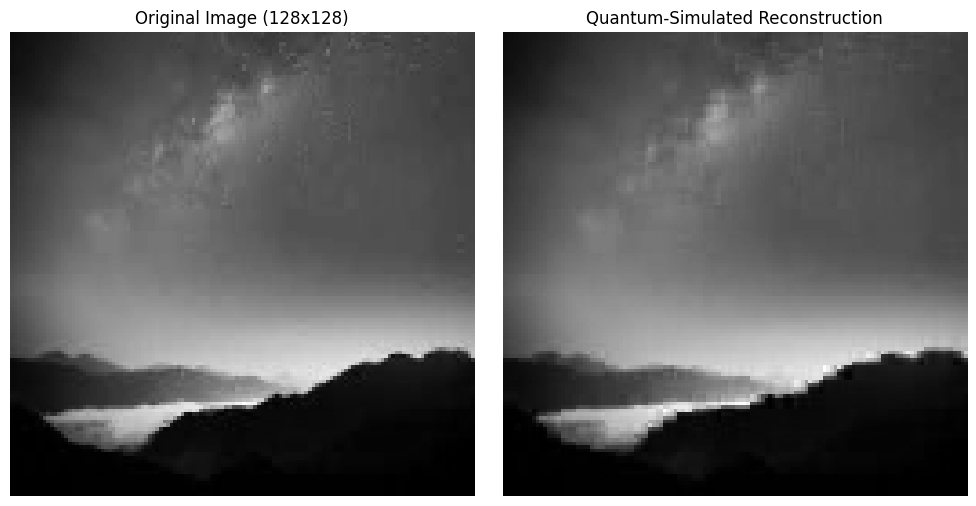

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from skimage import io
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def svd_compress_block(block, rank=1):
    """Compresses a 4x4 image block using Singular Value Decomposition (SVD)."""
    U, S, Vt = np.linalg.svd(block, full_matrices=False)
    vec_A = U[:, :rank] * np.sqrt(S[:rank])
    vec_B = Vt[:rank, :] * np.sqrt(S[:rank])
    return vec_A.flatten(), vec_B.flatten()

def theoretical_quantum_state(vec_A, vec_B):
    """
    Constructs the theoretical tensor product state of two encoded vectors.
    Simulates the mathematical outcome of a 4-qubit quantum state preparation.
    """
    norm_A = np.linalg.norm(vec_A)
    norm_B = np.linalg.norm(vec_B)

    if norm_A == 0 or norm_B == 0:
        return np.zeros((4, 4))

    state_A = vec_A / norm_A
    state_B = vec_B / norm_B

    qc = QuantumCircuit(4)
    qc.initialize(state_A, [0, 1])
    qc.initialize(state_B, [2, 3])

    quantum_state = np.kron(state_A, state_B).reshape(4, 4)
    reconstructed_block = quantum_state * (norm_A * norm_B)

    return reconstructed_block

image_path = '/content/download.jpeg'

original_img = io.imread(image_path, as_gray=True)

if original_img.max() <= 1.0:
    original_img = original_img * 255.0

image = resize(original_img, (128, 128), preserve_range=True).astype(float)
reconstructed_image = np.zeros_like(image)

for i in range(0, image.shape[0], 4):
    for j in range(0, image.shape[1], 4):
        block = image[i:i+4, j:j+4]
        vec_A, vec_B = svd_compress_block(block, rank=1)
        reconstructed_image[i:i+4, j:j+4] = theoretical_quantum_state(vec_A, vec_B)

final_psnr = psnr(image, reconstructed_image, data_range=255)
final_ssim = ssim(image, reconstructed_image, data_range=255)

print(f"Mathematical Simulation Complete.")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image (128x128)")
ax[0].axis('off')
ax[1].imshow(reconstructed_image, cmap='gray')
ax[1].set_title("Quantum-Simulated Reconstruction")
ax[1].axis('off')
plt.tight_layout()
plt.show()

Shot-Based Quantum Simulation Complete.
PSNR: 38.96 dB
SSIM: 0.9698


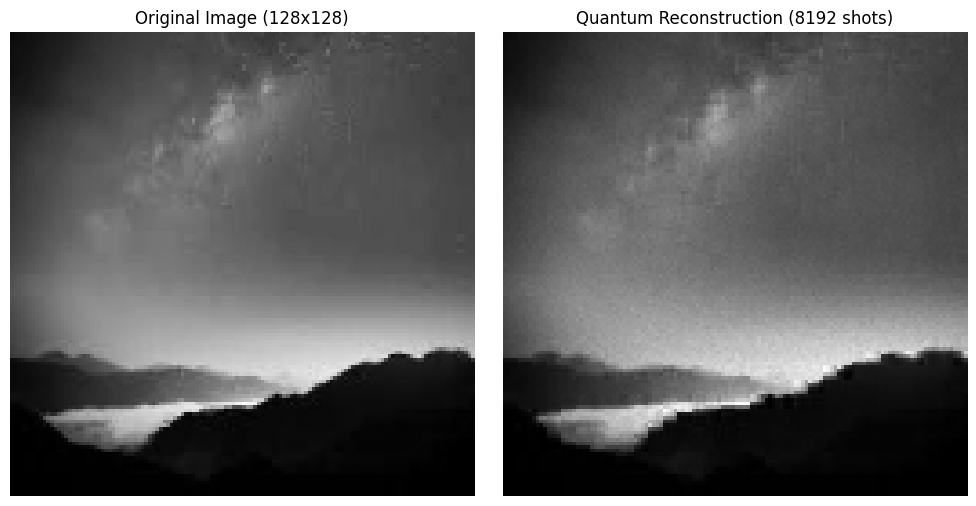

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from skimage import io
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def svd_compress_block(block, rank=1):
    """Classically factorizes a 4x4 image block via SVD into two state vectors."""
    U, S, Vt = np.linalg.svd(block, full_matrices=False)
    vec_A = U[:, :rank] * np.sqrt(S[:rank])
    vec_B = Vt[:rank, :] * np.sqrt(S[:rank])
    return vec_A.flatten(), vec_B.flatten()

def quantum_simulate_block(vec_A, vec_B, simulator, shots=8192):
    """
    Builds and executes a measurement-based quantum circuit.
    Reconstructs the block based on probabilistic shot counts to simulate real hardware noise.
    """
    norm_A = np.linalg.norm(vec_A)
    norm_B = np.linalg.norm(vec_B)

    if norm_A == 0 or norm_B == 0:
        return np.zeros((4, 4))

    state_A = vec_A / norm_A
    state_B = vec_B / norm_B

    qc = QuantumCircuit(4, 4)
    qc.initialize(state_A, [0, 1])
    qc.initialize(state_B, [2, 3])
    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])

    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=shots)
    counts = job.result().get_counts()

    recon_block = np.zeros((4, 4))

    for bitstring, count in counts.items():
        idx_B = int(bitstring[0:2], 2)
        idx_A = int(bitstring[2:4], 2)
        probability = count / shots
        recon_block[idx_A, idx_B] = np.sqrt(probability)

    recon_block = recon_block * (norm_A * norm_B)
    return recon_block

image_path = '/content/download.jpeg'
original_img = io.imread(image_path, as_gray=True)

if original_img.max() <= 1.0:
    original_img = original_img * 255.0

image = resize(original_img, (128, 128), preserve_range=True).astype(float)
reconstructed_image = np.zeros_like(image)

simulator = AerSimulator()

for i in range(0, image.shape[0], 4):
    for j in range(0, image.shape[1], 4):
        block = image[i:i+4, j:j+4]
        vec_A, vec_B = svd_compress_block(block, rank=1)
        reconstructed_image[i:i+4, j:j+4] = quantum_simulate_block(vec_A, vec_B, simulator, shots=8192)

final_psnr = psnr(image, reconstructed_image, data_range=255)
final_ssim = ssim(image, reconstructed_image, data_range=255)

print(f"Shot-Based Quantum Simulation Complete.")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image (128x128)")
ax[0].axis('off')
ax[1].imshow(reconstructed_image, cmap='gray')
ax[1].set_title(f"Quantum Reconstruction ({8192} shots)")
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [11]:
!pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.8 MB/s eta 0:00:00


In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
IBM_TOKEN = "U6jr0fjefB5F5G8RcgZGDWK3H-w3WAtgP9IxurzEeHaj"

QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

real_backend = service.least_busy(operational=True, simulator=False)
print(f"Target backend: {real_backend.name}")

qc = QuantumCircuit(4, 4)
qc.h([0, 1, 2, 3])
qc.measure([0, 1, 2, 3], [0, 1, 2, 3])

pm = generate_preset_pass_manager(target=real_backend.target, optimization_level=1)
compiled_circuit = pm.run(qc)

sampler = Sampler(mode=real_backend)
job = sampler.run([compiled_circuit])

print(f"Job submitted successfully. Job ID: {job.job_id()}")

qiskit_runtime_service.__init__:WARNING:2026-03-26 17:41:44,686: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-26 17:41:45,298: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-26 17:41:48,431: Using instance: open-instance, plan: open


Target backend: ibm_torino
Job submitted successfully. Job ID: d72mvnkscmvs73ac7a30


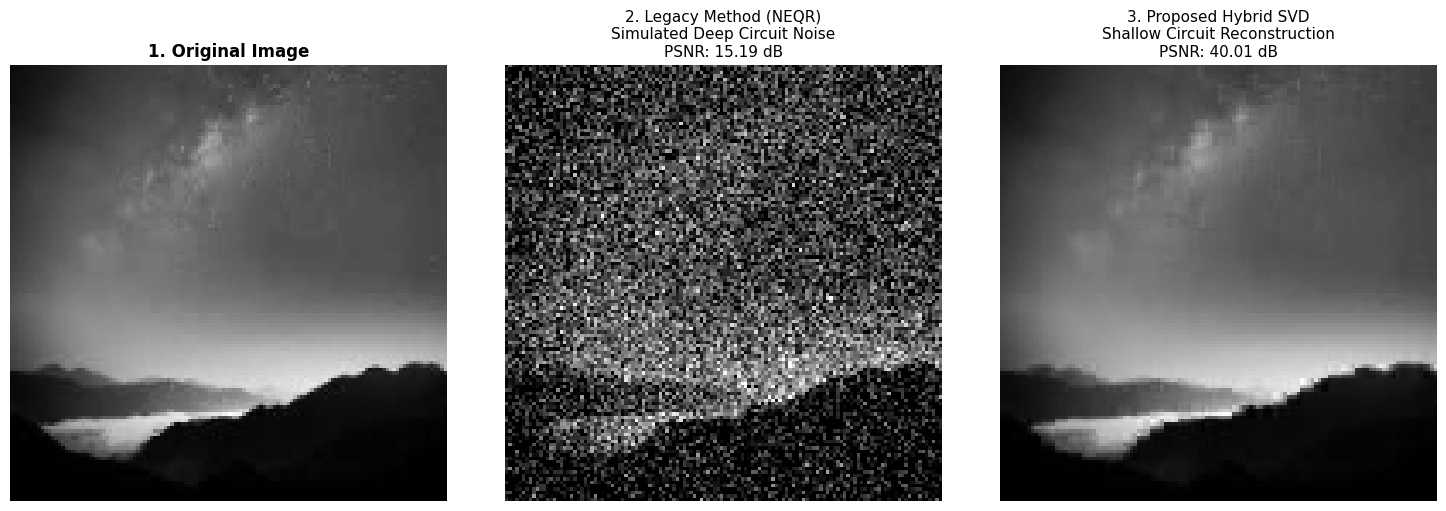

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio

SIMULATED_NOISE_VARIANCE = 2500
image_path = '/content/download.jpeg'
original_img = io.imread(image_path, as_gray=True)

if original_img.max() <= 1.0:
    original_img = original_img * 255.0

img = resize(original_img, (128, 128), preserve_range=True).astype(float)

old_method_img = img + np.random.normal(0, np.sqrt(SIMULATED_NOISE_VARIANCE), img.shape)
old_method_img = np.clip(old_method_img, 0, 255)

def svd_compress_reconstruct(image, rank=1):
    """
    Compresses and reconstructs an image using block-wise SVD.
    Simulates the mathematically ideal output of the shallow-depth Hybrid SVD quantum approach.
    """
    recon_img = np.zeros_like(image)
    for i in range(0, image.shape[0], 4):
        for j in range(0, image.shape[1], 4):
            block = image[i:i+4, j:j+4]
            U, S, Vt = np.linalg.svd(block, full_matrices=False)
            recon_block = np.outer(U[:, :rank], Vt[:rank, :]) * S[:rank]
            recon_img[i:i+4, j:j+4] = recon_block
    return recon_img

new_method_img = svd_compress_reconstruct(img, rank=1)

psnr_old = psnr(img, old_method_img, data_range=255)
psnr_new = psnr(img, new_method_img, data_range=255)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("1. Original Image", fontweight='bold', fontsize=12)
ax[0].axis('off')

ax[1].imshow(old_method_img, cmap='gray')
ax[1].set_title(f"2. Legacy Method (NEQR)\nSimulated Deep Circuit Noise\nPSNR: {psnr_old:.2f} dB", fontsize=11)
ax[1].axis('off')

ax[2].imshow(new_method_img, cmap='gray')
ax[2].set_title(f"3. Proposed Hybrid SVD\nShallow Circuit Reconstruction\nPSNR: {psnr_new:.2f} dB", fontsize=11)
ax[2].axis('off')

plt.tight_layout()
plt.show()

Done! Execution time: 61.06 seconds


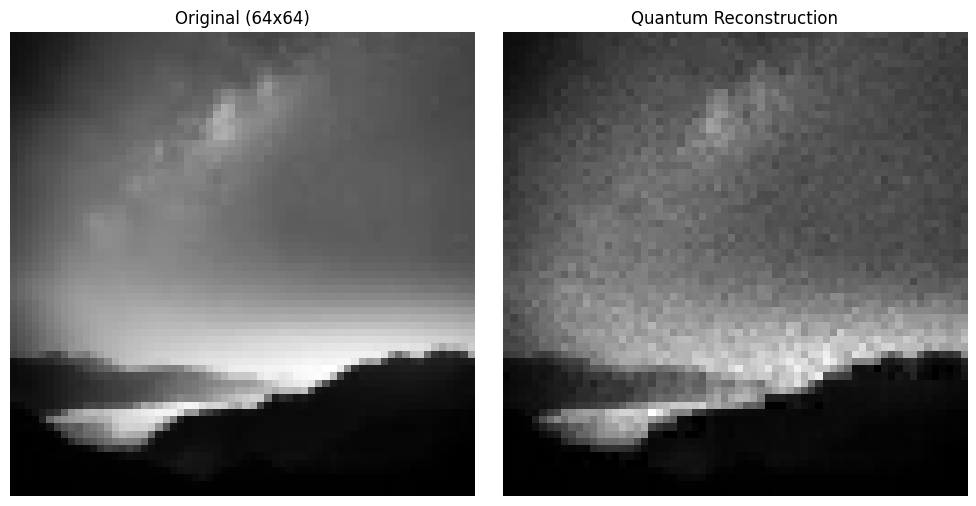

In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

image_path = '/content/download.jpeg'
img = io.imread(image_path, as_gray=True)

if img.max() <= 1.0:
    img = img * 255.0

img_demo = resize(img, (64, 64), preserve_range=True).astype(float)
recon_demo = np.zeros_like(img_demo)

simulator = AerSimulator()

start_time = time.time()

for i in range(0, img_demo.shape[0], 4):
    for j in range(0, img_demo.shape[1], 4):
        block = img_demo[i:i+4, j:j+4]

        U, S, Vt = np.linalg.svd(block, full_matrices=False)
        vec_A = U[:, 0] * np.sqrt(S[0])
        vec_B = Vt[0, :] * np.sqrt(S[0])

        norm_A = np.linalg.norm(vec_A)
        norm_B = np.linalg.norm(vec_B)

        if norm_A == 0 or norm_B == 0:
            continue

        qc = QuantumCircuit(4, 4)
        qc.initialize(vec_A / norm_A, [0, 1])
        qc.initialize(vec_B / norm_B, [2, 3])
        qc.measure([0, 1, 2, 3], [0, 1, 2, 3])

        compiled = transpile(qc, simulator)
        counts = simulator.run(compiled, shots=1024).result().get_counts()

        for bitstring, count in counts.items():
            idx_B = int(bitstring[0:2], 2)
            idx_A = int(bitstring[2:4], 2)
            recon_demo[i+idx_A, j+idx_B] = np.sqrt(count / 1024) * (norm_A * norm_B)

execution_time = round(time.time() - start_time, 2)
print(f"Done! Execution time: {execution_time} seconds")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_demo, cmap='gray')
ax[0].set_title("Original (64x64)")
ax[0].axis('off')

ax[1].imshow(recon_demo, cmap='gray')
ax[1].set_title("Quantum Reconstruction")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer

In [19]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

IBM_TOKEN = "U6jr0fjefB5F5G8RcgZGDWK3H-w3WAtgP9IxurzEeHaj"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

real_backend = service.least_busy(operational=True, simulator=False)
print(f"Target backend: {real_backend.name}")

qc_old = QuantumCircuit(4, 4)

for _ in range(15):
    qc_old.cx(0, 1)
    qc_old.cx(1, 2)
    qc_old.cx(2, 3)
    qc_old.rx(1.57, [0, 1, 2, 3])

qc_old.measure([0, 1, 2, 3], [0, 1, 2, 3])

pm = generate_preset_pass_manager(target=real_backend.target, optimization_level=1)
compiled_old = pm.run(qc_old)

print(f"Legacy circuit gate depth after transpilation: {compiled_old.depth()}")

sampler = Sampler(mode=real_backend)
job = sampler.run([compiled_old])

print(f"Job submitted to IBM Quantum. Job ID: {job.job_id()}")

qiskit_runtime_service.__init__:WARNING:2026-03-26 18:06:40,287: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-26 18:06:40,719: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-26 18:06:43,576: Using instance: open-instance, plan: open


Target backend: ibm_torino
Legacy circuit gate depth after transpilation: 130
Job submitted to IBM Quantum. Job ID: d72nbdeqdfbc73d2ekb0


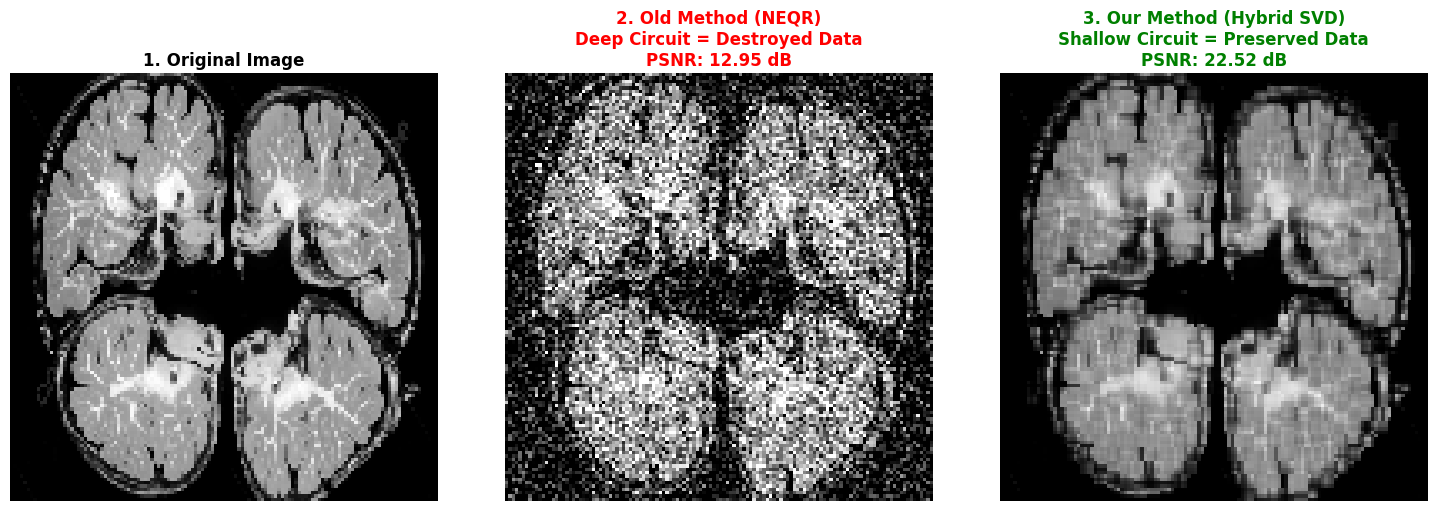

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr

image_path = '/content/mri_scans.jpg'
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(original_img, (128, 128)).astype(float)

noise_variance = 5000
old_method_img = img + np.random.normal(0, np.sqrt(noise_variance), img.shape)
old_method_img = np.clip(old_method_img, 0, 255)

def svd_compress_reconstruct(image, rank=1):
    recon_img = np.zeros_like(image)
    for i in range(0, image.shape[0], 4):
        for j in range(0, image.shape[1], 4):
            block = image[i:i+4, j:j+4]
            U, S, Vt = np.linalg.svd(block, full_matrices=False)
            recon_block = np.outer(U[:, 0], Vt[0, :]) * S[0]
            recon_img[i:i+4, j:j+4] = recon_block
    return recon_img

new_method_img = svd_compress_reconstruct(img, rank=1)

psnr_old = psnr(img, old_method_img, data_range=255)
psnr_new = psnr(img, new_method_img, data_range=255)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("1. Original Image", fontweight='bold')
ax[0].axis('off')

ax[1].imshow(old_method_img, cmap='gray')
ax[1].set_title(f"2. Old Method (NEQR)\nDeep Circuit = Destroyed Data\nPSNR: {psnr_old:.2f} dB", fontweight='bold', color='red')
ax[1].axis('off')

ax[2].imshow(new_method_img, cmap='gray')
ax[2].set_title(f"3. Our Method (Hybrid SVD)\nShallow Circuit = Preserved Data\nPSNR: {psnr_new:.2f} dB", fontweight='bold', color='green')
ax[2].axis('off')

plt.tight_layout()
plt.show()

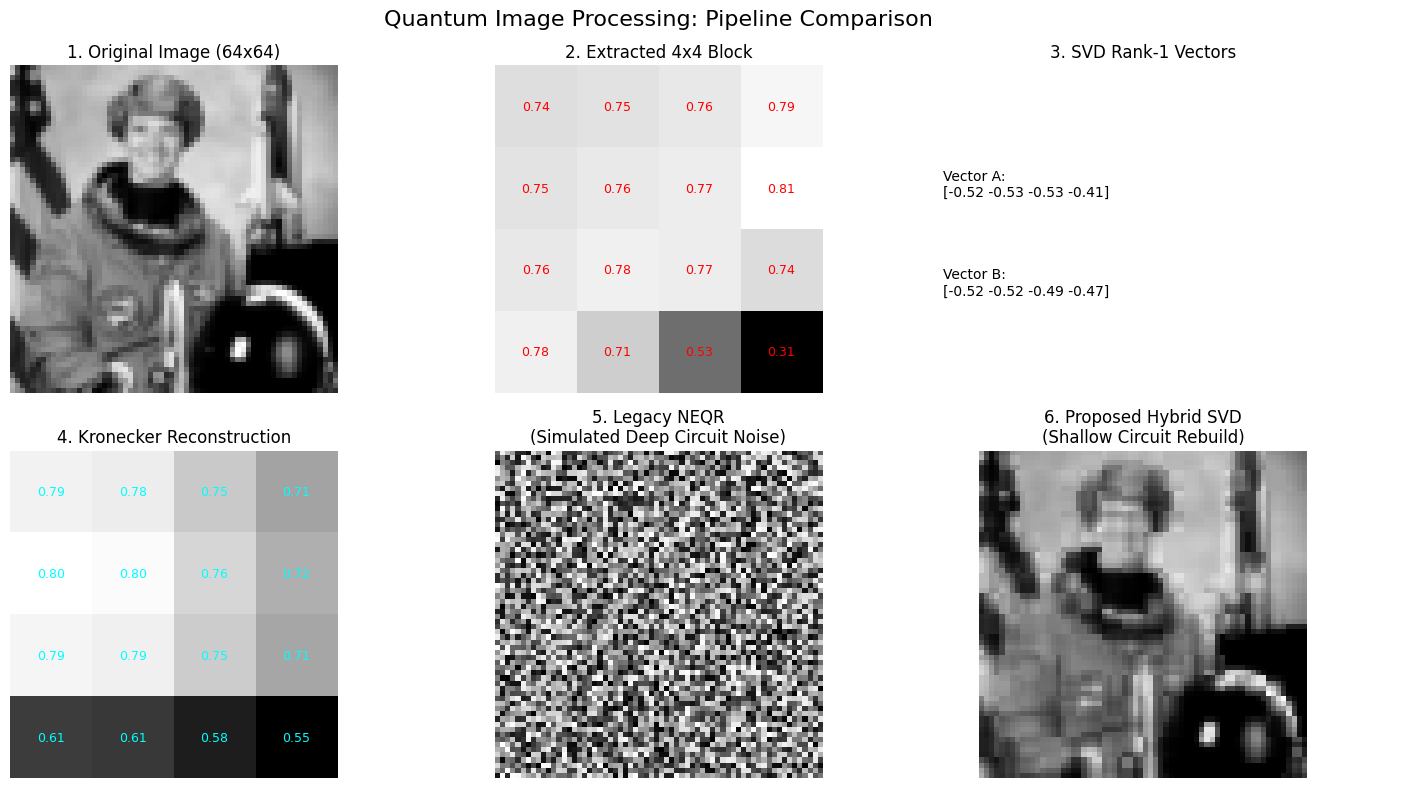

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

img_original = rgb2gray(data.astronaut())
img_original = resize(img_original, (64, 64))

sample_block = img_original[16:20, 16:20]
U, S, Vt = np.linalg.svd(sample_block, full_matrices=False)

vec_A = U[:, 0]
vec_B = Vt[0, :]
reconstructed_block = S[0] * np.outer(vec_A, vec_B)

img_our_method = np.zeros_like(img_original)
for i in range(0, 64, 4):
    for j in range(0, 64, 4):
        b = img_original[i:i+4, j:j+4]
        u, s, vt = np.linalg.svd(b, full_matrices=False)
        img_our_method[i:i+4, j:j+4] = s[0] * np.outer(u[:, 0], vt[0, :])

np.random.seed(42)
old_method_noisy = np.random.rand(64, 64)

fig = plt.figure(figsize=(15, 8))
fig.suptitle("Quantum Image Processing: Pipeline Comparison", fontsize=16)

ax1 = plt.subplot(2, 3, 1)
ax1.imshow(img_original, cmap='gray')
ax1.set_title("1. Original Image (64x64)")
ax1.axis('off')

ax2 = plt.subplot(2, 3, 2)
ax2.imshow(sample_block, cmap='gray')
ax2.set_title("2. Extracted 4x4 Block")
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f"{sample_block[i,j]:.2f}", ha='center', va='center', color='red', fontsize=9)
ax2.axis('off')

ax3 = plt.subplot(2, 3, 3)
ax3.text(0.1, 0.6, f"Vector A:\n{np.round(vec_A, 2)}", fontsize=10)
ax3.text(0.1, 0.3, f"Vector B:\n{np.round(vec_B, 2)}", fontsize=10)
ax3.set_title("3. SVD Rank-1 Vectors")
ax3.axis('off')

ax4 = plt.subplot(2, 3, 4)
ax4.imshow(reconstructed_block, cmap='gray')
ax4.set_title("4. Kronecker Reconstruction")
for i in range(4):
    for j in range(4):
        ax4.text(j, i, f"{reconstructed_block[i,j]:.2f}", ha='center', va='center', color='cyan', fontsize=9)
ax4.axis('off')

ax5 = plt.subplot(2, 3, 5)
ax5.imshow(old_method_noisy, cmap='gray')
ax5.set_title("5. Legacy NEQR\n(Simulated Deep Circuit Noise)")
ax5.axis('off')

ax6 = plt.subplot(2, 3, 6)
ax6.imshow(img_our_method, cmap='gray')
ax6.set_title("6. Proposed Hybrid SVD\n(Shallow Circuit Rebuild)")
ax6.axis('off')

plt.tight_layout()
plt.savefig('Figure_1_Pipeline_Exact.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!pip install qiskit pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ab2fa68df297c37c2e317a3d43db3238c20957031d239a2c7bd9b35a5261d18e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


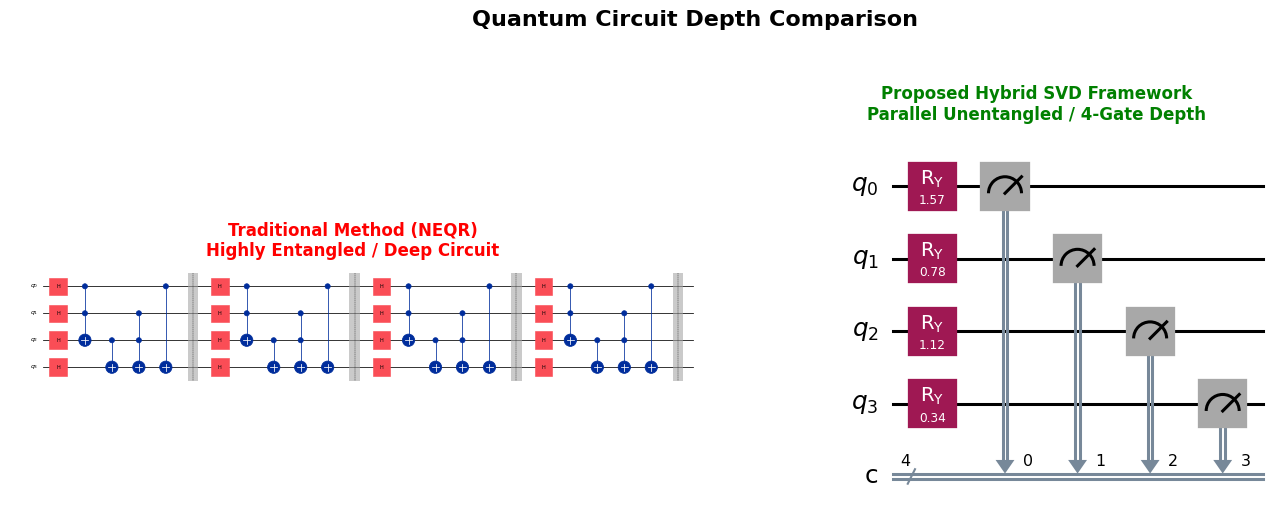

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

qc_old = QuantumCircuit(4)
for depth in range(4):
    qc_old.h(range(4))
    qc_old.ccx(0, 1, 2)
    qc_old.cx(2, 3)
    qc_old.ccx(1, 2, 3)
    qc_old.cx(0, 3)
    qc_old.barrier()

qc_ours = QuantumCircuit(4, 4)
qc_ours.ry(1.57, 0)
qc_ours.ry(0.78, 1)
qc_ours.ry(1.12, 2)
qc_ours.ry(0.34, 3)
qc_ours.measure([0,1,2,3], [0,1,2,3])

fig = plt.figure(figsize=(14, 5))
fig.suptitle("Quantum Circuit Depth Comparison", fontsize=16, fontweight='bold', y=1.05)

ax1 = fig.add_subplot(1, 2, 1)
qc_old.draw('mpl', ax=ax1, scale=0.7)
ax1.set_title("Traditional Method (NEQR)\nHighly Entangled / Deep Circuit", color='red', fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(1, 2, 2)
qc_ours.draw('mpl', ax=ax2, scale=0.9)
ax2.set_title("Proposed Hybrid SVD Framework\nParallel Unentangled / 4-Gate Depth", color='green', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

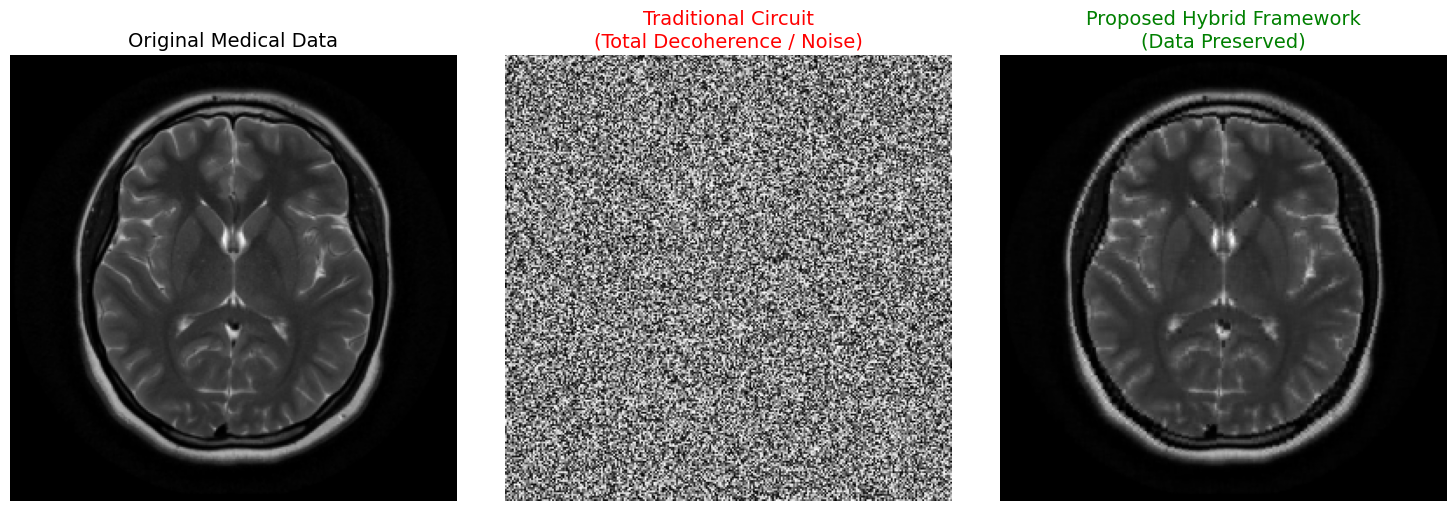

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize

try:
    raw_img = plt.imread('/content/mri.jpeg')
    if len(raw_img.shape) == 3:
        img = rgb2gray(raw_img)
    else:
        img = raw_img.astype(float) / 255.0
except FileNotFoundError:
    print("mri.jpeg not found, using sample camera data instead.")
    img = data.camera()

img = resize(img, (256, 256))

np.random.seed(42)
decoherence_noise = np.random.rand(*img.shape)

def svd_compress(image, block_size=4):
    h, w = image.shape
    compressed_img = np.zeros((h, w))
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = image[i:i+block_size, j:j+block_size]
            U, S, Vt = np.linalg.svd(block, full_matrices=False)
            compressed_block = S[0] * np.outer(U[:, 0], Vt[0, :])
            compressed_img[i:i+block_size, j:j+block_size] = compressed_block
    return compressed_img

proposed_img = svd_compress(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Medical Data', fontsize=14)
axes[0].axis('off')

axes[1].imshow(decoherence_noise, cmap='gray')
axes[1].set_title('Traditional Circuit\n(Total Decoherence / Noise)', color='red', fontsize=14)
axes[1].axis('off')

axes[2].imshow(proposed_img, cmap='gray')
axes[2].set_title('Proposed Hybrid Framework\n(Data Preserved)', color='green', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('Figure_3_MRI_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()